# 3. The physics toolkit

`physics` has **no terrain in it**. It is closed-form physics that the scan needs but
cannot measure from a DEM: how much atmosphere a shower develops in, how much Earth a
neutrino crossed, how far a tau travels before it decays.

It is usable entirely on its own, which is the point of this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from oroscope import physics
from oroscope import figures

## The tau decay length

$L = (E/m_\tau)\,c\tau$. This sets the scale of every useful detector-to-target
distance, and it is exactly analytic — no simulation input at all.

In [2]:
for e in (1.0, 3.0, 10.0, 100.0, 1000.0):
    print(f"{e:>7.0f} PeV   L = {physics.tau_decay_length_m(e):>10,.0f} m")

print()
print("TAMBO's published 50 m - 5 km tau range corresponds to about 1-100 PeV,")
print("and GRAND's 10-80 km window to roughly 0.2-1.6 EeV.")

      1 PeV   L =         49 m
      3 PeV   L =        147 m
     10 PeV   L =        490 m
    100 PeV   L =      4,898 m
   1000 PeV   L =     48,980 m

TAMBO's published 50 m - 5 km tau range corresponds to about 1-100 PeV,
and GRAND's 10-80 km window to roughly 0.2-1.6 EeV.


This is why a **single energy cannot stand in for a spectrum** when a search depends on
the tau decaying inside a gap. Across a 3 km canyon crossing the probability runs from
essentially one to a few per cent over one experiment's energy reach.

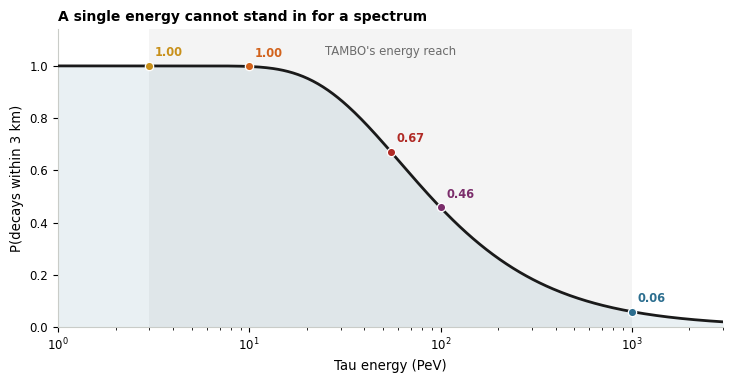

In [3]:
figures.decay_and_shower()
plt.show()

## Shower development is measured in grammage, not metres

Air at 4000 m is a third thinner than at sea level, so a site search comparing
candidates at different altitudes while measuring path length in metres is comparing
unlike things.

In [4]:
for alt in (0.0, 2000.0, 4000.0):
    x = physics.slant_grammage_gcm2(alt, 0.0, 20000.0)
    rho = physics.air_density_kgm3(alt)
    print(f"20 km horizontal at {alt:>6,.0f} m:  rho = {rho:.3f} kg/m^3   X = {x:>6,.0f} g/cm^2")

20 km horizontal at      0 m:  rho = 1.225 kg/m^3   X =  2,450 g/cm^2
20 km horizontal at  2,000 m:  rho = 0.965 kg/m^3   X =  1,931 g/cm^2
20 km horizontal at  4,000 m:  rho = 0.761 kg/m^3   X =  1,522 g/cm^2


What counts as "enough" depends on **what is being detected**, and the two cases differ:

- **Radio** — emission comes from around shower maximum and then propagates through air
  that is transparent at 50–200 MHz. Being far past maximum costs nothing, so the
  criterion is a *threshold*.
- **Particles** — the charged-particle content peaks at maximum and dies after, so the
  criterion is genuinely a *band*.

The band follows from the primary energy through the shower profile.

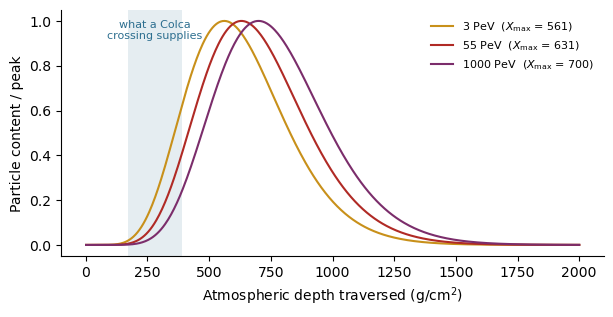

band at a tenth of peak content, 3 PeV - 1 EeV: 236 - 1287 g/cm^2


In [5]:
x = np.linspace(1, 2000, 500)
fig, ax = plt.subplots(figsize=(7, 3.2))
for e, c in ((3.0, "#C8901A"), (55.0, "#B02A25"), (1000.0, "#7B2D6B")):
    xmax = float(physics.shower_maximum_gcm2(e))
    ax.plot(x, physics.shower_size_fraction(x, xmax), color=c,
            label=f"{e:g} PeV  ($X_{{\\rm max}}$ = {xmax:.0f})")
ax.axvspan(170, 390, color="#2C6E8F", alpha=0.12, lw=0)
ax.text(280, 0.92, "what a Colca\ncrossing supplies", ha="center", fontsize=8,
        color="#2C6E8F")
ax.set_xlabel("Atmospheric depth traversed (g/cm$^2$)")
ax.set_ylabel("Particle content / peak")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

lo, hi = physics.grammage_band_from_energy(3.0, 1000.0, fraction=0.1)
print(f"band at a tenth of peak content, 3 PeV - 1 EeV: {lo:.0f} - {hi:.0f} g/cm^2")

That shaded strip is the whole siting problem for a canyon experiment: a crossing
supplies only the air its own width contains. The default particle band of
$(X_{\rm max},\,4X_{\rm max})$ = 700–2800 g/cm² rejects **every** canyon.

## The Earth chord

For downgoing directions the neutrino has crossed a chord $2R\sin\theta$, which dwarfs
local topography.

In [6]:
lam = physics.neutrino_interaction_length_gcm2(1000.0)
print(f"interaction length at 1 EeV: {lam:.2e} g/cm^2\n")
for theta in (-0.5, -1.0, -2.0, -3.0, -5.0):
    chord_km = physics.earth_chord_m(theta) / 1000
    surv = physics.neutrino_survival(theta, lam)
    print(f"{theta:>5.1f} deg:  chord {chord_km:>6,.0f} km   survival {surv:.3f}")

interaction length at 1 EeV: 1.65e+08 g/cm^2

 -0.5 deg:  chord    111 km   survival 0.836
 -1.0 deg:  chord    222 km   survival 0.700
 -2.0 deg:  chord    445 km   survival 0.489
 -3.0 deg:  chord    667 km   survival 0.342
 -5.0 deg:  chord  1,111 km   survival 0.168


This is a **falsifiable prediction**: the effective arrival window should narrow with
energy, its lower edge climbing toward the horizon.

In [7]:
for e in (100.0, 1000.0, 10000.0):
    cut = physics.earth_absorption_cutoff_deg(e)
    print(f"{e:>7,.0f} PeV:  window lower edge at {cut:+.1f} deg")

print()
print("If a collaboration's simulated window does not narrow this way,")
print("one of the two treatments has the absorption wrong.")

    100 PeV:  window lower edge at -4.4 deg
  1,000 PeV:  window lower edge at -2.0 deg
 10,000 PeV:  window lower edge at -0.9 deg

If a collaboration's simulated window does not narrow this way,
one of the two treatments has the absorption wrong.


## Geomagnetic emission

Radio emission goes as $|\vec v \times \vec B|$: a shower travelling *along* the field
radiates almost none of it. Peru sits near the magnetic equator, where the field is
nearly horizontal and northward — so north–south showers are strongly suppressed.

In [8]:
dec, inc = physics.default_field_for_site(-16.4, -71.5)
B = physics.geomagnetic_unit_vector(dec, inc)
print(f"Arequipa field: declination {dec:.1f} deg, inclination {inc:.1f} deg\n")

for name, az in (("north", 0.0), ("north-east", 45.0), ("east", 90.0)):
    print(f"{name:>10}-facing target:  sin(alpha) = "
          f"{physics.geomagnetic_sin_alpha(az, 0.0, B):.3f}")

print("\nEast-facing targets are worth several times north-facing ones,")
print("which no purely geometric measure can see.")

Arequipa field: declination -6.9 deg, inclination -14.0 deg

     north-facing target:  sin(alpha) = 0.268
north-east-facing target:  sin(alpha) = 0.801
      east-facing target:  sin(alpha) = 0.993

East-facing targets are worth several times north-facing ones,
which no purely geometric measure can see.


## Where to go next

- **[4. Criteria and scoring](04_criteria_and_scoring.ipynb)** — combining all of this
  into one comparable number, and the trap in doing so.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [The arrival scan](02_the_arrival_scan.ipynb). Next: [Criteria and scoring](04_criteria_and_scoring.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*